In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

In [2]:
f = '../data/inversion_pib/conjunto_de_datos/inversion_inv.csv'
inversion_inv = pd.read_csv(f, usecols=[0,1,2,3], na_values=['ND', 'NAN'])

In [3]:
inversion_inv.head()

,Periodo,Producto_Interno_Bruto_Anual,Inversion_en_Innovacion,Porcentaje
0,2024,33980509.00,72962.49,0.21
1,2025,34650228.03,71108.76,0.21
2,2023,31935813.01,68549.17,0.21
3,2015,19228614.68,63216.53,0.33
4,2014,18137650.62,61462.31,0.34


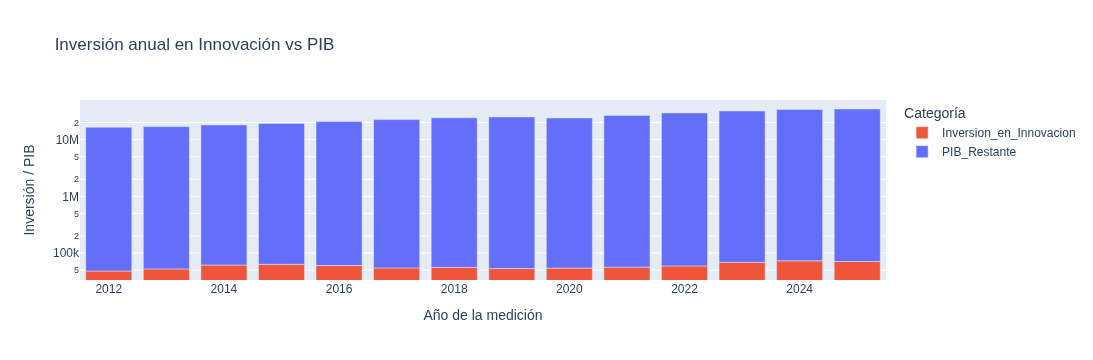

In [5]:
inversion_inv['PIB_Restante'] = inversion_inv['Producto_Interno_Bruto_Anual'] - inversion_inv['Inversion_en_Innovacion']

df_plot = inversion_inv.melt(
    id_vars=['Periodo'], 
    value_vars=['Inversion_en_Innovacion', 'PIB_Restante'],
    var_name='Concepto', 
    value_name='Monto'
)

fig = px.bar(
    df_plot,
    x="Periodo",
    y="Monto",
    color="Concepto",
    log_y=True, 
    title="Inversión anual en Innovación vs PIB",
    labels={
        "Periodo": "Año de la medición",
        "Monto": "Inversión / PIB",
        "Concepto": "Categoría"
    },
    
    color_discrete_map={
        "PIB_Restante": "#636EFA", 
        "Inversion_en_Innovacion": "#EF553B"
    }
)

fig.update_layout(xaxis={'categoryorder':'category ascending'})

fig.show()